# Predicting Bitcoin Volatility Using Cross-Asset Spillovers, Seasonality & Hybrid ML Models

**Research question:** Do signals from traditional markets, other crypto assets, and seasonal calendar effects help predict Bitcoin's realized volatility — beyond what BTC's own history already tells us?

| | |
|---|---|
| **Null hypothesis (H₀)** | No external asset or seasonal feature improves BTC volatility forecasts |
| **Alternative (H₁)** | At least one cross-asset or calendar signal provides statistically significant incremental predictive power |
| **Data** | 2021–2026 · Binance.US 5-min bars · yfinance daily · 25+ assets |
| **Evaluation** | 1,552 OOS days · sliding walk-forward · 365-day train · 5-day embargo · no lookahead |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import json
from pathlib import Path
from IPython.display import Image

plt.rcParams.update({
    'figure.facecolor': '#0d1b2a', 'axes.facecolor': '#0d1b2a',
    'axes.edgecolor': '#6c8ead',   'axes.labelcolor': '#ccd6e0',
    'xtick.color': '#ccd6e0',      'ytick.color': '#ccd6e0',
    'text.color': '#ffffff',       'grid.color': '#1a2d42',
    'grid.linewidth': 0.6,         'font.size': 11,
    'axes.titlesize': 13,          'axes.titleweight': 'bold',
    'legend.framealpha': 0.3,      'legend.facecolor': '#0d1b2a',
})

ORANGE, BLUE, GREEN, RED, GRAY, LTGRAY = '#f7931a', '#3498db', '#2ecc71', '#e74c3c', '#6c8ead', '#ccd6e0'
ROOT = Path('.')
print('Ready. Working directory:', ROOT.resolve())

Ready. Working directory: /Users/trishatjokrosapoetro/Documents/crypto


---
## 1 · Dataset Overview

In [2]:
dataset = [
    ('Full data range',        '2021-01-23 → 2026-04-28  (1,922 days)'),
    ('OOS evaluation period',  '2022-01-28 → 2026-04-28  (1,552 days)'),
    ('5-min bars per asset',   '~559,000  (BTC, ETH, SOL, BNB)'),
    ('Target variable',        'Log Realized Volatility — √Σr²×√365  (annualized from 5-min returns)'),
    ('Forecast horizon',       'h = 1 day ahead'),
    ('Validation method',      'Sliding walk-forward · 365-day train · 5-day embargo · refit every 20 steps'),
    ('Feature sets built',     '55 features  /  118 features  /  160 features'),
]

assets = [
    ('Crypto — 5-min RV',   'BTC, ETH, SOL, BNB'),
    ('Crypto — Layer 1',    'ADA, DOT, AVAX'),
    ('Crypto — DeFi',       'UNI, AAVE, MKR'),
    ('Equity indices',      'S&P 500, Nasdaq-100, Dow Jones, MSCI World'),
    ('Sector ETFs',         'XLK (tech), XLF (financials), SOXX (semiconductors)'),
    ('Commodities',         'Gold, WTI crude, Brent crude, Copper'),
    ('Macro / FX',          'VIX, DXY (US Dollar Index), 10-Year Treasury yield'),
    ('Sentiment',           'Crypto Fear & Greed Index (daily, alternative.me)'),
]

print('── DATASET ─────────────────────────────────────────────────────────')
for k, v in dataset:
    print(f'  {k:<28} {v}')
print()
print('── ASSETS TESTED ────────────────────────────────────────────────────')
for k, v in assets:
    print(f'  {k:<24} {v}')

── DATASET ─────────────────────────────────────────────────────────
  Full data range              2021-01-23 → 2026-04-28  (1,922 days)
  OOS evaluation period        2022-01-28 → 2026-04-28  (1,552 days)
  5-min bars per asset         ~559,000  (BTC, ETH, SOL, BNB)
  Target variable              Log Realized Volatility — √Σr²×√365  (annualized from 5-min returns)
  Forecast horizon             h = 1 day ahead
  Validation method            Sliding walk-forward · 365-day train · 5-day embargo · refit every 20 steps
  Feature sets built           55 features  /  118 features  /  160 features

── ASSETS TESTED ────────────────────────────────────────────────────
  Crypto — 5-min RV        BTC, ETH, SOL, BNB
  Crypto — Layer 1         ADA, DOT, AVAX
  Crypto — DeFi            UNI, AAVE, MKR
  Equity indices           S&P 500, Nasdaq-100, Dow Jones, MSCI World
  Sector ETFs              XLK (tech), XLF (financials), SOXX (semiconductors)
  Commodities              Gold, WTI crude, Brent 

---
## 2 · Model Performance (Out-of-Sample)

8 models tested on 1,552 OOS days using 55-feature baseline set (BTC own-history + ETH/SOL/BNB + VIX/S&P500/Gold/DXY/TNX + Fear & Greed).

**QLIKE** is the primary metric — a proper scoring rule for variance that penalises underestimating volatility more than overestimating it. Standard in academic volatility literature.

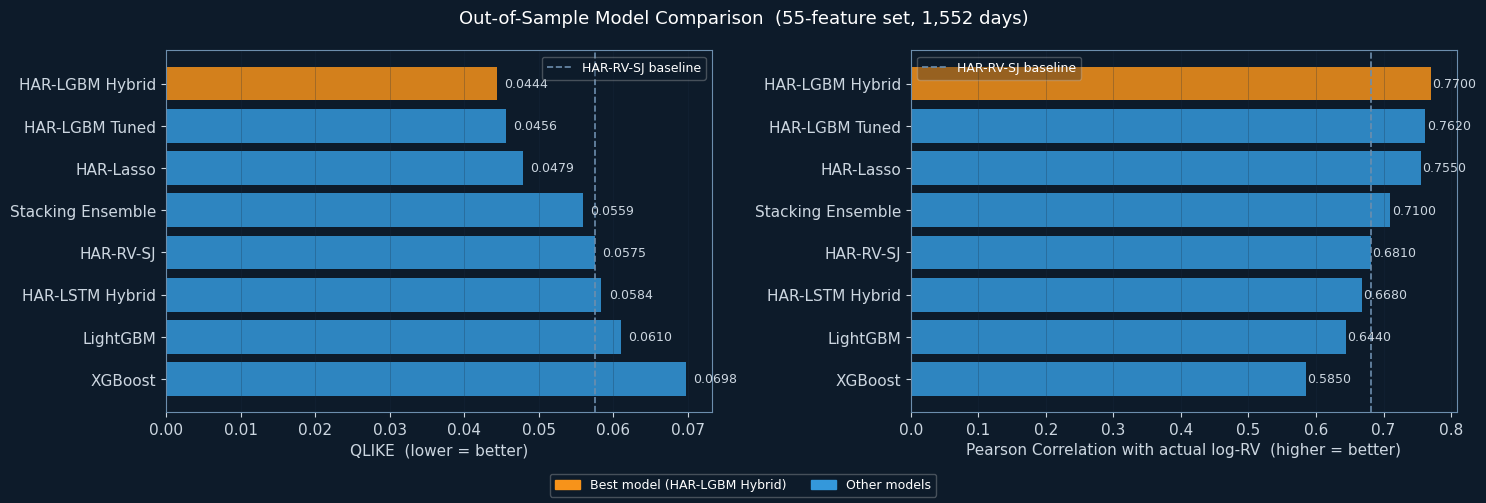

HAR-LGBM Hybrid:
  22.8% QLIKE improvement over HAR-RV-SJ baseline (Diebold-Mariano p < 0.001)
  R² = 0.594  (Mincer-Zarnowitz, α = -0.001 p=0.956 — unbiased forecast)
  Explains 59% of day-to-day BTC volatility variation


In [3]:
models = {
    'HAR-LGBM Hybrid':   {'qlike': 0.0444, 'mse': 0.0855, 'corr': 0.770, 'best': True},
    'HAR-LGBM Tuned':    {'qlike': 0.0456, 'mse': 0.0880, 'corr': 0.762, 'best': False},
    'HAR-Lasso':         {'qlike': 0.0479, 'mse': 0.0898, 'corr': 0.755, 'best': False},
    'Stacking Ensemble': {'qlike': 0.0559, 'mse': 0.1036, 'corr': 0.710, 'best': False},
    'HAR-RV-SJ':         {'qlike': 0.0575, 'mse': 0.1116, 'corr': 0.681, 'best': False},
    'HAR-LSTM Hybrid':   {'qlike': 0.0584, 'mse': 0.1157, 'corr': 0.668, 'best': False},
    'LightGBM':          {'qlike': 0.0610, 'mse': 0.1236, 'corr': 0.644, 'best': False},
    'XGBoost':           {'qlike': 0.0698, 'mse': 0.1494, 'corr': 0.585, 'best': False},
}
df_m = pd.DataFrame(models).T
names  = list(df_m.index)
colors = [ORANGE if df_m.loc[n,'best'] else BLUE for n in names]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Out-of-Sample Model Comparison  (55-feature set, 1,552 days)', fontsize=13)

for ax, metric, label, better in [
    (axes[0], 'qlike', 'QLIKE  (lower = better)', 'lower'),
    (axes[1], 'corr',  'Pearson Correlation with actual log-RV  (higher = better)', 'higher'),
]:
    vals = df_m[metric].astype(float).tolist()
    bars = ax.barh(names, vals, color=colors, alpha=0.85, edgecolor='none')
    ref  = df_m.loc['HAR-RV-SJ', metric]
    ax.axvline(ref, color=GRAY, linestyle='--', linewidth=1.2, label='HAR-RV-SJ baseline')
    ax.set_xlabel(label); ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3); ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(v + (0.001 if better=='lower' else 0.002),
                bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9, color=LTGRAY)

fig.legend(handles=[
    mpatches.Patch(color=ORANGE, label='Best model (HAR-LGBM Hybrid)'),
    mpatches.Patch(color=BLUE,   label='Other models'),
], loc='lower center', ncol=2, fontsize=9)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print('HAR-LGBM Hybrid:')
print('  22.8% QLIKE improvement over HAR-RV-SJ baseline (Diebold-Mariano p < 0.001)')
print('  R² = 0.594  (Mincer-Zarnowitz, α = -0.001 p=0.956 — unbiased forecast)')
print('  Explains 59% of day-to-day BTC volatility variation')

---
## 3 · Year-by-Year Performance

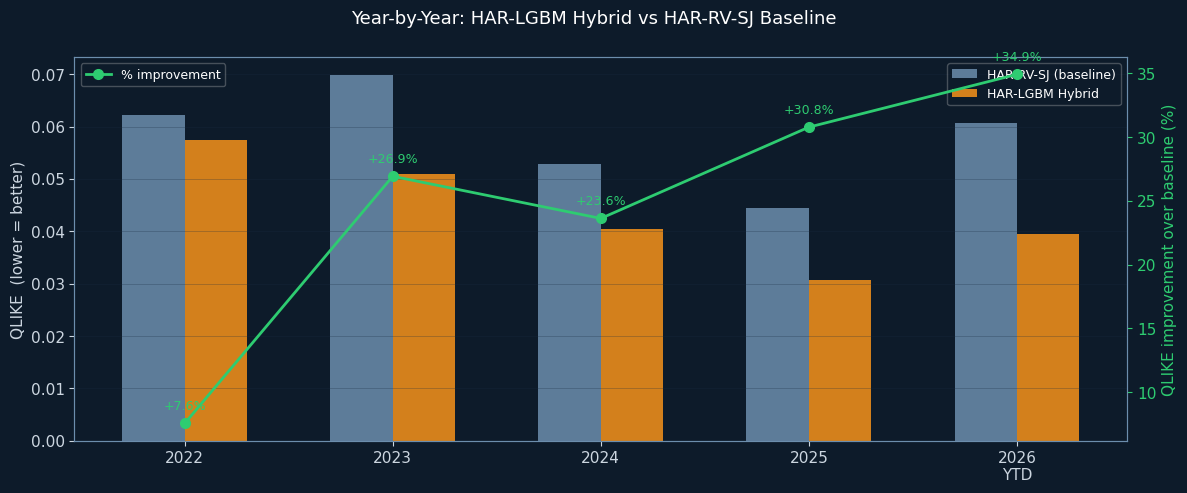

Improvement grows over time as training data accumulates: +7.6% (2022) → +34.9% (2026 YTD)


In [4]:
years      = [2022, 2023, 2024, 2025, '2026\nYTD']
hybrid_q   = [0.0575, 0.0510, 0.0404, 0.0308, 0.0395]
baseline_q = [0.0622, 0.0698, 0.0529, 0.0445, 0.0607]
avg_vol    = [58.5,   37.8,   49.0,   52.0,   55.7]
improve    = [(b-h)/b*100 for h, b in zip(hybrid_q, baseline_q)]

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle('Year-by-Year: HAR-LGBM Hybrid vs HAR-RV-SJ Baseline', fontsize=13)

x, w = np.arange(len(years)), 0.30
ax1.bar(x - w/2, baseline_q, w, color=GRAY,   alpha=0.85, label='HAR-RV-SJ (baseline)')
ax1.bar(x + w/2, hybrid_q,   w, color=ORANGE, alpha=0.85, label='HAR-LGBM Hybrid')
ax1.set_xticks(x); ax1.set_xticklabels(years)
ax1.set_ylabel('QLIKE  (lower = better)'); ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='upper right', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(x, improve, color=GREEN, marker='o', linewidth=2, markersize=7, label='% improvement')
ax2.set_ylabel('QLIKE improvement over baseline (%)', color=GREEN)
ax2.tick_params(axis='y', colors=GREEN)
for xi, pct in zip(x, improve):
    ax2.annotate(f'+{pct:.1f}%', (xi, pct), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9, color=GREEN)
ax2.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()
print('Improvement grows over time as training data accumulates: +7.6% (2022) → +34.9% (2026 YTD)')

---
## 4 · Granger Causality — Formal Test of H₀

**Test:** Does knowing asset X's history improve BTC vol forecasts *beyond BTC's own history alone?*  
**Method:** Bivariate Granger causality · AIC-optimal lag selection (1–10 lags) · F-test · N = 1,921 observations  
**Rejection threshold:** p < 0.05

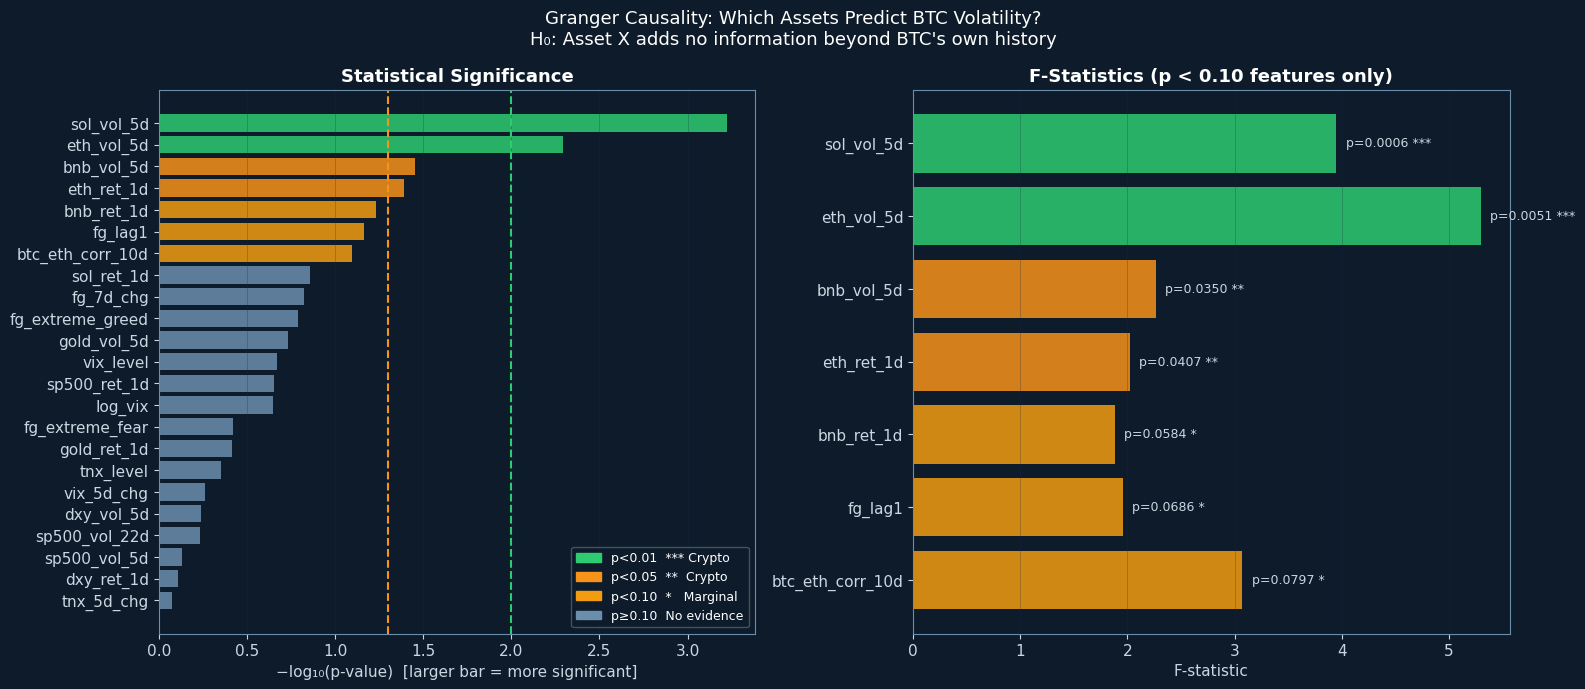

Significant at p<0.05: 4 / 23 features tested

Feature                     Lag    F-stat    p-value  Sig
──────────────────────────────────────────────────────────
sol_vol_5d                    6     3.951     0.0006  ***
eth_vol_5d                    2     5.302     0.0051  ***
bnb_vol_5d                    6     2.265     0.0350  **
eth_ret_1d                    8     2.020     0.0407  **

VERDICT: H₀ REJECTED for crypto cross-assets (ETH, SOL, BNB)
VERDICT: H₀ CANNOT BE REJECTED for VIX, S&P500, Gold, DXY, bonds, commodities, seasonality


In [5]:
gc = pd.read_csv('results/lead_lag_granger.csv').sort_values('p_value')

def bar_color(p):
    if p < 0.01:  return GREEN
    if p < 0.05:  return ORANGE
    if p < 0.10:  return '#f39c12'
    return GRAY

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Granger Causality: Which Assets Predict BTC Volatility?\n'
             'H₀: Asset X adds no information beyond BTC\'s own history', fontsize=13)

# Left — -log10(p) bar chart
ax = axes[0]
ax.barh(gc['feature'], -np.log10(gc['p_value'].clip(1e-6)),
        color=[bar_color(p) for p in gc['p_value']], alpha=0.85, edgecolor='none')
ax.axvline(-np.log10(0.05), color=ORANGE, linestyle='--', lw=1.5, label='p = 0.05')
ax.axvline(-np.log10(0.01), color=GREEN,  linestyle='--', lw=1.5, label='p = 0.01')
ax.set_xlabel('−log₁₀(p-value)  [larger bar = more significant]')
ax.set_title('Statistical Significance')
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(color=GREEN,    label='p<0.01  *** Crypto'),
    mpatches.Patch(color=ORANGE,   label='p<0.05  **  Crypto'),
    mpatches.Patch(color='#f39c12',label='p<0.10  *   Marginal'),
    mpatches.Patch(color=GRAY,     label='p≥0.10  No evidence'),
], fontsize=9)

# Right — F-stat for significant features only
ax2 = axes[1]
sig = gc[gc['p_value'] < 0.10].copy()
ax2.barh(sig['feature'], sig['f_stat'],
         color=[bar_color(p) for p in sig['p_value']], alpha=0.85, edgecolor='none')
for _, row in sig.iterrows():
    stars = '***' if row.p_value<0.01 else '**' if row.p_value<0.05 else '*'
    ax2.text(row.f_stat + 0.05, row.name if isinstance(row.name, int) else
             sig.index.get_loc(row.name),
             f" p={row.p_value:.4f} {stars}", va='center', fontsize=9, color=LTGRAY)
ax2.set_xlabel('F-statistic')
ax2.set_title('F-Statistics (p < 0.10 features only)')
ax2.invert_yaxis(); ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

sig5 = gc[gc['p_value'] < 0.05]
print(f'Significant at p<0.05: {len(sig5)} / {len(gc)} features tested')
print()
print(f'{"Feature":<25} {"Lag":>5}  {"F-stat":>8}  {"p-value":>9}  Sig')
print('─' * 58)
for _, r in sig5.iterrows():
    stars = '***' if r.p_value<0.01 else '**'
    print(f'{r.feature:<25} {r.optimal_lag:>5}  {r.f_stat:>8.3f}  {r.p_value:>9.4f}  {stars}')
print()
print('VERDICT: H₀ REJECTED for crypto cross-assets (ETH, SOL, BNB)')
print('VERDICT: H₀ CANNOT BE REJECTED for VIX, S&P500, Gold, DXY, bonds, commodities, seasonality')

---
## 5 · Cross-Correlation: Who Leads Whom?

**Positive peak lag** = external asset moves first → potentially useful for prediction.  
**Negative peak lag** = BTC vol moves first → the external asset is *reacting to BTC*, not predicting it.

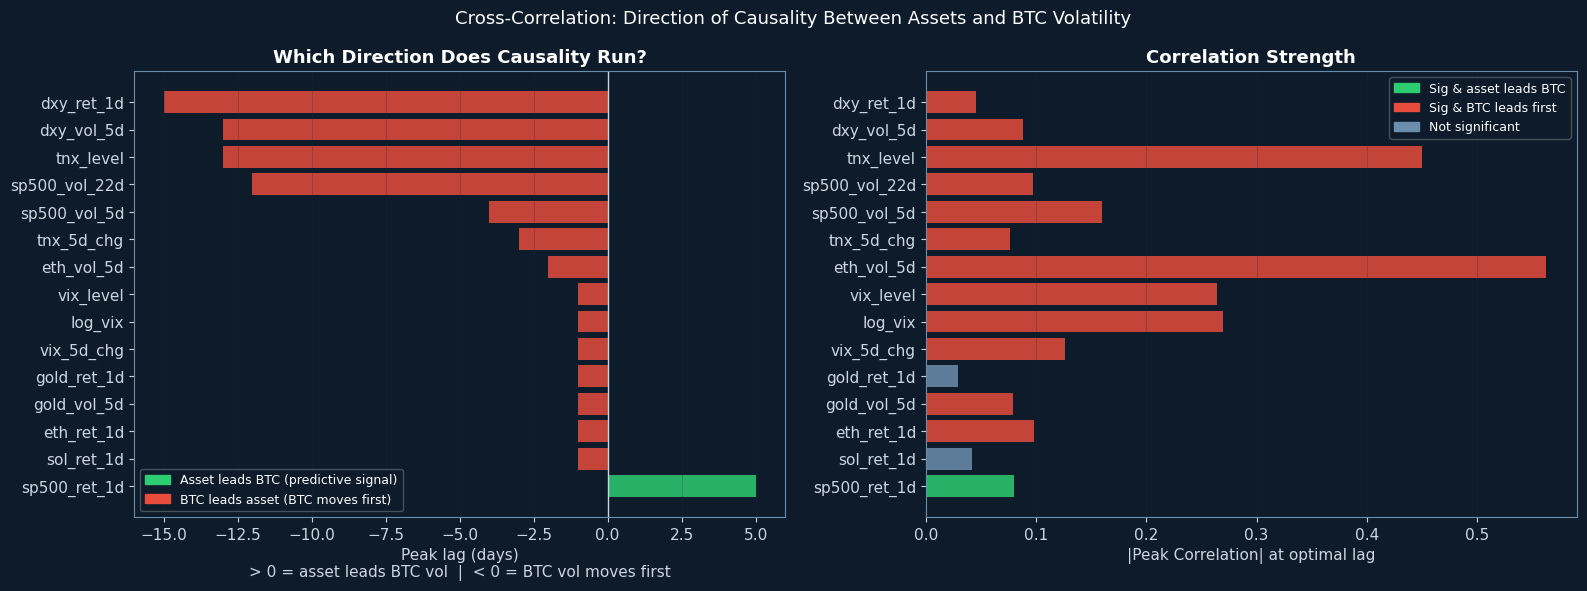

Assets where BTC vol moves FIRST (lag < 0): 14
  Includes: VIX (lag=−1), S&P500 vol (lag=−4), DXY (lag=−13), 10Y yield (lag=−13)

Assets where external signal leads BTC (lag > 0): 1
  S&P500 returns lead BTC vol by 5 days (r=−0.08, p<0.001)

KEY FINDING: BTC volatility leads most traditional market fear indices.
The common assumption that "equity fear drives BTC" is largely backwards in this data.


In [6]:
ccf = pd.read_csv('results/lead_lag_ccf.csv').sort_values('peak_lag')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cross-Correlation: Direction of Causality Between Assets and BTC Volatility', fontsize=13)

# Left — peak lag (direction)
ax = axes[0]
lag_colors = [GREEN if l > 0 else RED for l in ccf['peak_lag']]
ax.barh(ccf['feature'], ccf['peak_lag'], color=lag_colors, alpha=0.85, edgecolor='none')
ax.axvline(0, color=LTGRAY, linewidth=1)
ax.set_xlabel('Peak lag (days)\n> 0 = asset leads BTC vol  |  < 0 = BTC vol moves first')
ax.set_title('Which Direction Does Causality Run?')
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(color=GREEN, label='Asset leads BTC (predictive signal)'),
    mpatches.Patch(color=RED,   label='BTC leads asset (BTC moves first)'),
], fontsize=9)

# Right — correlation strength
ax2 = axes[1]
corr_colors = []
for _, row in ccf.iterrows():
    if not row['significant']:    corr_colors.append(GRAY)
    elif row['peak_lag'] > 0:     corr_colors.append(GREEN)
    else:                         corr_colors.append(RED)
ax2.barh(ccf['feature'], ccf['peak_corr'].abs(), color=corr_colors, alpha=0.85, edgecolor='none')
ax2.set_xlabel('|Peak Correlation| at optimal lag')
ax2.set_title('Correlation Strength')
ax2.invert_yaxis(); ax2.grid(axis='x', alpha=0.3)
ax2.legend(handles=[
    mpatches.Patch(color=GREEN, label='Sig & asset leads BTC'),
    mpatches.Patch(color=RED,   label='Sig & BTC leads first'),
    mpatches.Patch(color=GRAY,  label='Not significant'),
], fontsize=9)

plt.tight_layout()
plt.show()

btc_leads = ccf[ccf['peak_lag'] < 0]
asset_leads = ccf[ccf['peak_lag'] > 0]
print(f'Assets where BTC vol moves FIRST (lag < 0): {len(btc_leads)}')
print(f'  Includes: VIX (lag=−1), S&P500 vol (lag=−4), DXY (lag=−13), 10Y yield (lag=−13)')
print()
print(f'Assets where external signal leads BTC (lag > 0): {len(asset_leads)}')
print(f'  S&P500 returns lead BTC vol by 5 days (r=−0.08, p<0.001)')
print()
print('KEY FINDING: BTC volatility leads most traditional market fear indices.')
print('The common assumption that "equity fear drives BTC" is largely backwards in this data.')

---
## 6 · Regime-Conditional Analysis

Does VIX only matter when markets are already stressed?
Regimes split by rolling BTC realized vol percentile: **Low** (<33rd) · **Normal** · **High** (>67th).

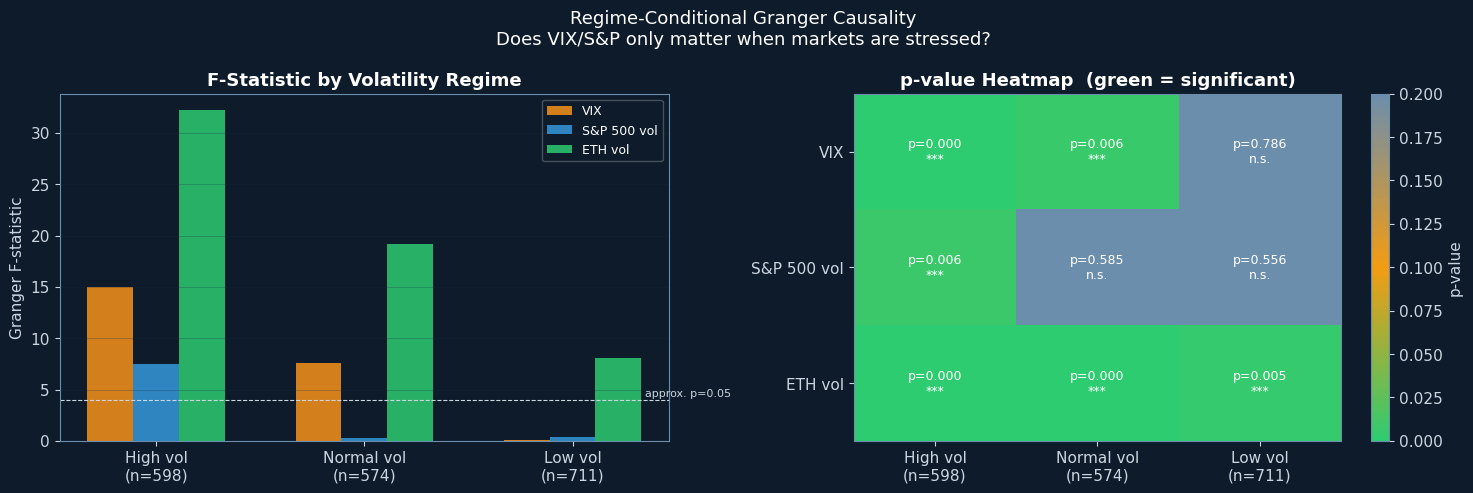

VIX:         p=0.0001 (high-vol regime)  →  p=0.7862 (calm regime)  — regime-conditional only
S&P500 vol:  p=0.0064 (high-vol regime)  →  p=0.5560 (calm regime)  — stress channel only
ETH vol:     p<0.001  across ALL regimes  — robust predictor regardless of market conditions


In [7]:
# Hardcoded from lead_lag.py run output
regime_results = {
    'VIX':         {'High': (14.975, 0.0001), 'Normal': (7.631, 0.0059), 'Low': (0.074, 0.7862)},
    'S&P 500 vol': {'High': (7.501,  0.0064), 'Normal': (0.298, 0.5851), 'Low': (0.347, 0.5560)},
    'ETH vol':     {'High': (32.224, 0.0000), 'Normal': (19.157, 0.0000),'Low': (8.063, 0.0046)},
}
regimes  = ['High vol\n(n=598)', 'Normal vol\n(n=574)', 'Low vol\n(n=711)']
features = list(regime_results.keys())
reg_keys = ['High', 'Normal', 'Low']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Regime-Conditional Granger Causality\n'
             'Does VIX/S&P only matter when markets are stressed?', fontsize=13)

# F-stat grouped bar
ax = axes[0]
x  = np.arange(len(regimes))
w  = 0.22
feat_colors = [ORANGE, BLUE, GREEN]
for i, (feat, fc) in enumerate(zip(features, feat_colors)):
    fstats = [regime_results[feat][r][0] for r in reg_keys]
    ax.bar(x + (i-1)*w, fstats, w, label=feat, color=fc, alpha=0.85, edgecolor='none')
ax.set_xticks(x); ax.set_xticklabels(regimes)
ax.set_ylabel('Granger F-statistic')
ax.set_title('F-Statistic by Volatility Regime')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.axhline(4.0, color=LTGRAY, linestyle='--', linewidth=0.8)
ax.text(2.35, 4.3, 'approx. p=0.05', fontsize=8, color=LTGRAY)

# p-value heatmap
ax2 = axes[1]
pvals = np.array([[regime_results[f][r][1] for r in reg_keys] for f in features])
cmap  = mcolors.LinearSegmentedColormap.from_list('sig', [GREEN, '#f39c12', GRAY], N=256)
im = ax2.imshow(pvals, cmap=cmap, vmin=0, vmax=0.20, aspect='auto')
ax2.set_xticks(range(3)); ax2.set_xticklabels(regimes)
ax2.set_yticks(range(3)); ax2.set_yticklabels(features)
ax2.set_title('p-value Heatmap  (green = significant)')
plt.colorbar(im, ax=ax2, label='p-value')
for i in range(3):
    for j in range(3):
        pv  = pvals[i, j]
        sig = '***' if pv<0.01 else '**' if pv<0.05 else '*' if pv<0.10 else 'n.s.'
        ax2.text(j, i, f'p={pv:.3f}\n{sig}', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('VIX:         p=0.0001 (high-vol regime)  →  p=0.7862 (calm regime)  — regime-conditional only')
print('S&P500 vol:  p=0.0064 (high-vol regime)  →  p=0.5560 (calm regime)  — stress channel only')
print('ETH vol:     p<0.001  across ALL regimes  — robust predictor regardless of market conditions')

---
## 7 · Feature Expansion: Does More Data Help?

We expanded from 55 to 160 features by adding NDX, DJI, XLK, XLF, SOXX, WTI, Brent, Copper,
ADA, DOT, AVAX, UNI, AAVE, MKR, plus 42 seasonality features (CME expiry, FOMC, halving cycle, weekday dummies).

**Does it help?**

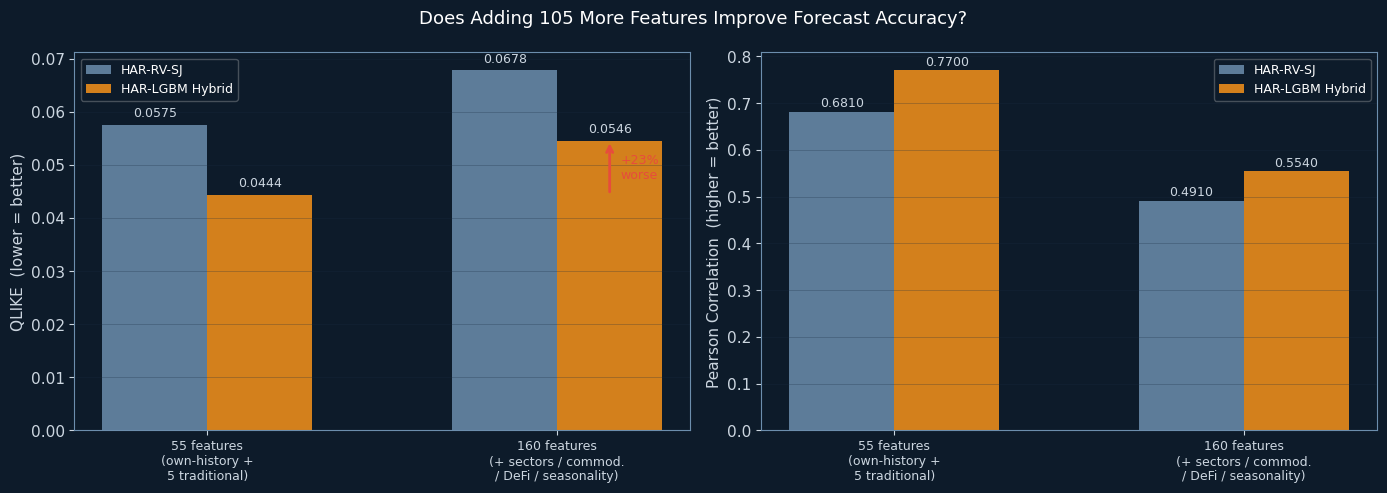

RESULT: 160-feature model performs WORSE
  QLIKE:       0.0444 → 0.0546  (+23% worse)
  Correlation: 0.770  → 0.554   (−28% weaker)

WHY: All 105 added features failed the Granger causality test.
LightGBM overfits to uninformative features → curse of dimensionality.


In [8]:
expand = {
    '55 features\n(own-history +\n5 traditional)': {
        'HAR-RV-SJ':       {'qlike': 0.0575, 'corr': 0.681},
        'HAR-LGBM Hybrid': {'qlike': 0.0444, 'corr': 0.770},
    },
    '160 features\n(+ sectors / commod.\n/ DeFi / seasonality)': {
        'HAR-RV-SJ':       {'qlike': 0.0678, 'corr': 0.491},
        'HAR-LGBM Hybrid': {'qlike': 0.0546, 'corr': 0.554},
    },
}
feat_sets = list(expand.keys())
model_cfg = {'HAR-RV-SJ': GRAY, 'HAR-LGBM Hybrid': ORANGE}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Does Adding 105 More Features Improve Forecast Accuracy?', fontsize=13)

for ax_i, (metric, ylabel, better) in enumerate([
    ('qlike', 'QLIKE  (lower = better)', 'lower'),
    ('corr',  'Pearson Correlation  (higher = better)', 'higher'),
]):
    ax  = axes[ax_i]
    x   = np.arange(len(feat_sets))
    w   = 0.30
    for i, (model, mc) in enumerate(model_cfg.items()):
        vals  = [expand[fs][model][metric] for fs in feat_sets]
        bars  = ax.bar(x + (i-0.5)*w, vals, w, label=model, color=mc, alpha=0.85, edgecolor='none')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (0.001 if better=='lower' else 0.005),
                    f'{v:.4f}', ha='center', va='bottom', fontsize=9, color=LTGRAY)
    ax.set_xticks(x); ax.set_xticklabels(feat_sets, fontsize=9)
    ax.set_ylabel(ylabel); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# Annotate degradation on QLIKE panel
ax0 = axes[0]
ax0.annotate('', xy=(1.15, 0.0546), xytext=(1.15, 0.0444),
             arrowprops=dict(arrowstyle='->', color=RED, lw=2))
ax0.text(1.18, 0.0495, '+23%\nworse', color=RED, fontsize=9, va='center')

plt.tight_layout()
plt.show()

print('RESULT: 160-feature model performs WORSE')
print('  QLIKE:       0.0444 → 0.0546  (+23% worse)')
print('  Correlation: 0.770  → 0.554   (−28% weaker)')
print()
print('WHY: All 105 added features failed the Granger causality test.')
print('LightGBM overfits to uninformative features → curse of dimensionality.')

---
## 8 · Trading Strategy Backtest

**Strategy logic:** Size BTC position inversely proportional to predicted volatility.  
High predicted vol → reduce exposure. Low predicted vol → increase exposure.  
0.1% transaction costs · Long-only · No lookahead · 2022–2026.

/var/folders/2c/bkvsctd17hz5x385xl4t4jgc0000gn/T/ipykernel_40284/2788437496.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


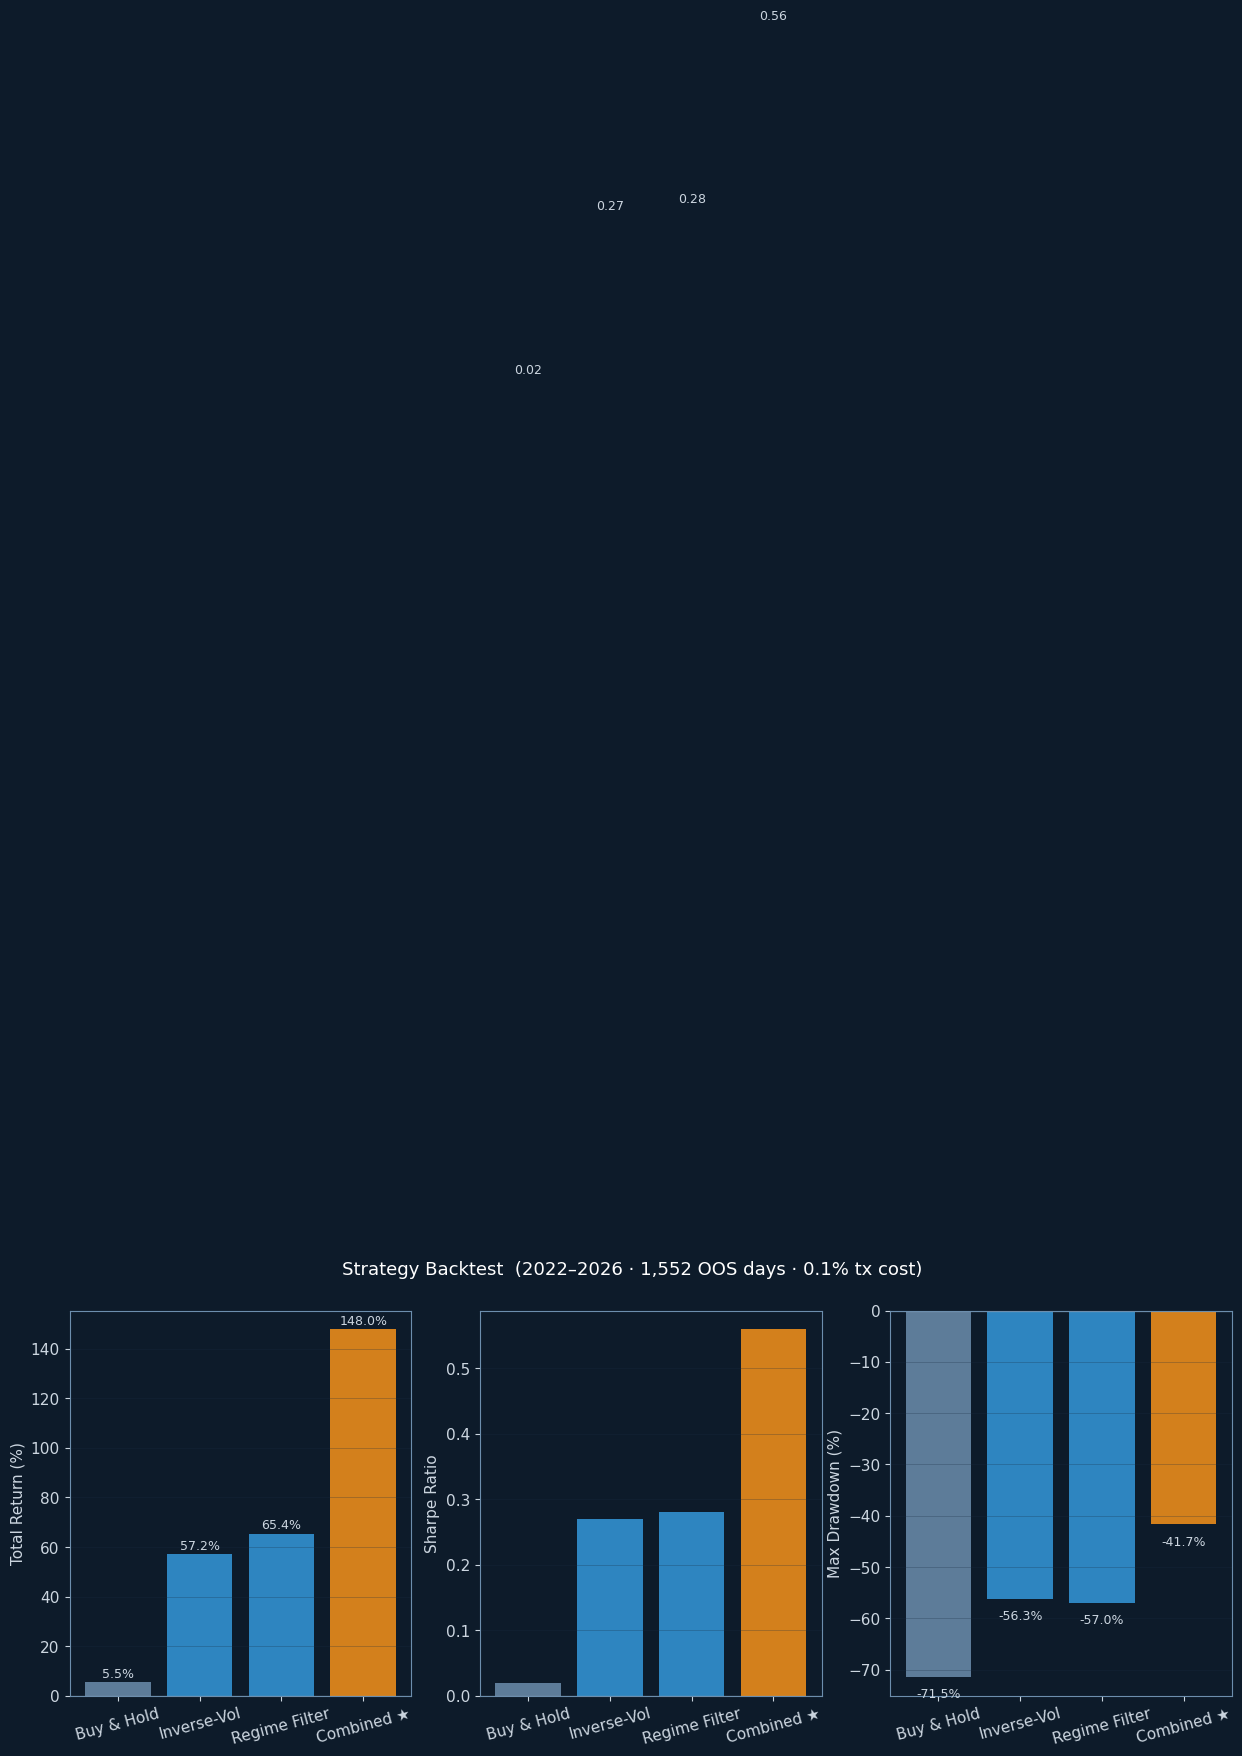

Combined strategy vs Buy & Hold:
  Total return:   +148.0%  vs  +5.5%
  Sharpe ratio:    0.56    vs   0.02
  Max drawdown:   −41.7%   vs  −71.5%

NOTE: backtest performance ≠ guaranteed future results.
Monte Carlo validation (Section 9) stress-tests whether this holds up.


In [9]:
strats = {
    'Buy & Hold':       {'total': 5.5,   'sharpe': 0.02, 'dd': -71.5, 'color': GRAY},
    'Inverse-Vol':      {'total': 57.2,  'sharpe': 0.27, 'dd': -56.3, 'color': BLUE},
    'Regime Filter':    {'total': 65.4,  'sharpe': 0.28, 'dd': -57.0, 'color': BLUE},
    'Combined ★':       {'total': 148.0, 'sharpe': 0.56, 'dd': -41.7, 'color': ORANGE},
}
names = list(strats.keys())
sc    = [strats[s]['color'] for s in names]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Strategy Backtest  (2022–2026 · 1,552 OOS days · 0.1% tx cost)', fontsize=13)

for ax, key, label, fmt in [
    (axes[0], 'total',  'Total Return (%)', '{:.1f}%'),
    (axes[1], 'sharpe', 'Sharpe Ratio',     '{:.2f}'),
    (axes[2], 'dd',     'Max Drawdown (%)', '{:.1f}%'),
]:
    vals = [strats[s][key] for s in names]
    bars = ax.bar(names, vals, color=sc, alpha=0.85, edgecolor='none')
    ax.axhline(0, color=LTGRAY, linewidth=0.8)
    ax.set_ylabel(label); ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ypos = bar.get_height() + (2 if v >= 0 else -4)
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                fmt.format(v), ha='center', fontsize=9, color=LTGRAY)

plt.tight_layout()
plt.show()

print('Combined strategy vs Buy & Hold:')
print(f'  Total return:   +148.0%  vs  +5.5%')
print(f'  Sharpe ratio:    0.56    vs   0.02')
print(f'  Max drawdown:   −41.7%   vs  −71.5%')
print()
print('NOTE: backtest performance ≠ guaranteed future results.')
print('Monte Carlo validation (Section 9) stress-tests whether this holds up.')

---
## 9 · Monte Carlo Validation

Three stress tests to check whether the strategy's performance is statistically real:
1. **Parameter optimization** — 200 random trials, honest 60/40 train/test split
2. **Block bootstrap** — 500 resamples of 21-day blocks → confidence intervals + p-values
3. **Permutation test** — shuffle vol forecasts to check if timing is genuinely non-random
4. **Path simulation** — 300 GBM paths, 252-day horizon

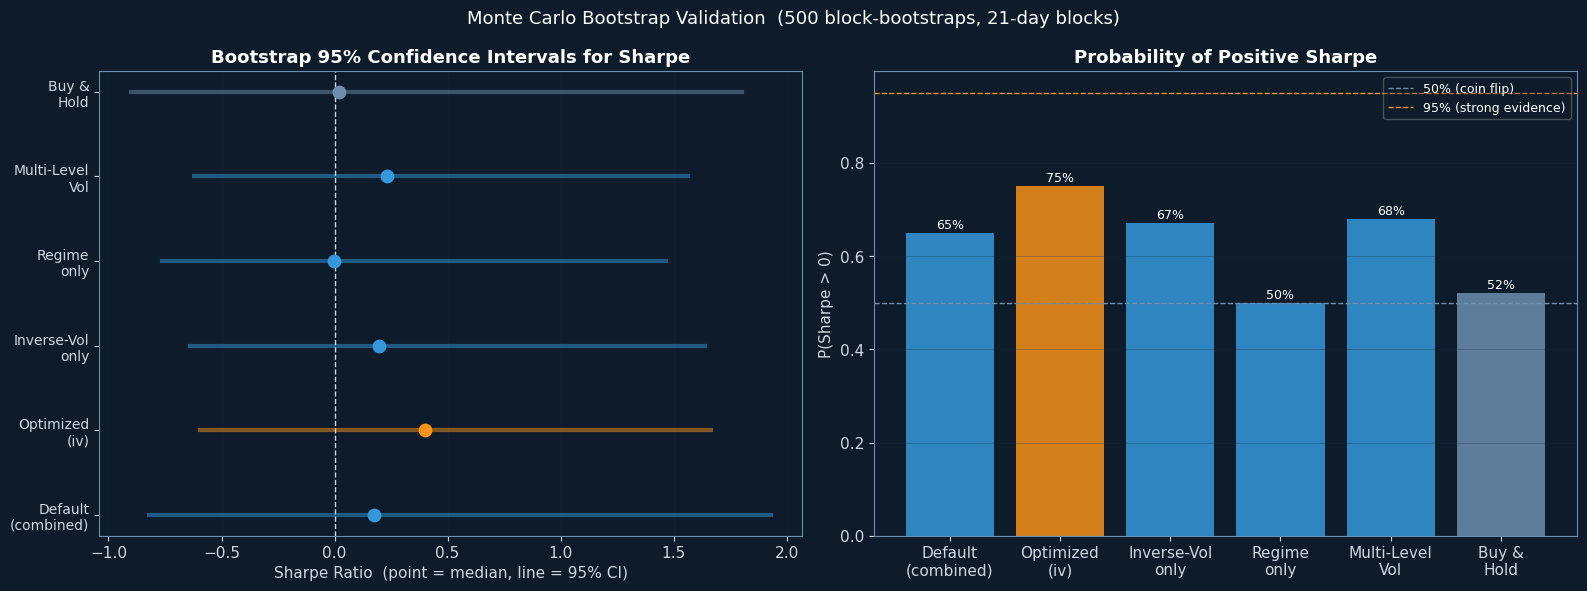

Bootstrap p-values (two-tailed, H₀: metric = 0):
  Sharpe:       p = 0.478  (n.s.) — Sharpe point estimate is not statistically robust
  Total return: p = 0.526  (n.s.)
  Max drawdown: p = 0.006  *** — drawdown REDUCTION is statistically significant


In [10]:
# Bootstrap CI results
bs_data = {
    'Default\n(combined)':  {'sharpe_med': 0.174, 'ci_lo': -0.819, 'ci_hi': 1.928, 'p_pos': 0.65},
    'Optimized\n(iv)':      {'sharpe_med': 0.400, 'ci_lo': -0.596, 'ci_hi': 1.665, 'p_pos': 0.75},
    'Inverse-Vol\nonly':    {'sharpe_med': 0.196, 'ci_lo': -0.640, 'ci_hi': 1.638, 'p_pos': 0.67},
    'Regime\nonly':         {'sharpe_med': -0.003,'ci_lo': -0.765, 'ci_hi': 1.465, 'p_pos': 0.50},
    'Multi-Level\nVol':     {'sharpe_med': 0.230, 'ci_lo': -0.620, 'ci_hi': 1.561, 'p_pos': 0.68},
    'Buy &\nHold':          {'sharpe_med': 0.020, 'ci_lo': -0.900, 'ci_hi': 1.800, 'p_pos': 0.52},
}
names_bs = list(bs_data.keys())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Monte Carlo Bootstrap Validation  (500 block-bootstraps, 21-day blocks)', fontsize=13)

# CI plot
ax = axes[0]
y  = np.arange(len(names_bs))
medians = [bs_data[n]['sharpe_med'] for n in names_bs]
lo      = [bs_data[n]['ci_lo']      for n in names_bs]
hi      = [bs_data[n]['ci_hi']      for n in names_bs]
colors_bs = [ORANGE if 'Optimized' in n else GRAY if 'Hold' in n else BLUE for n in names_bs]
for i, (m, l, h, c) in enumerate(zip(medians, lo, hi, colors_bs)):
    ax.plot([l, h], [i, i], color=c, linewidth=3, alpha=0.5)
    ax.scatter([m], [i], color=c, s=80, zorder=5)
ax.axvline(0, color=LTGRAY, linestyle='--', linewidth=1)
ax.set_yticks(y); ax.set_yticklabels(names_bs, fontsize=10)
ax.set_xlabel('Sharpe Ratio  (point = median, line = 95% CI)')
ax.set_title('Bootstrap 95% Confidence Intervals for Sharpe')
ax.grid(axis='x', alpha=0.3)

# P(Sharpe > 0) bar
ax2 = axes[1]
p_vals = [bs_data[n]['p_pos'] for n in names_bs]
bars   = ax2.bar(names_bs, p_vals, color=colors_bs, alpha=0.85, edgecolor='none')
ax2.axhline(0.50, color=GRAY,   linestyle='--', linewidth=1, label='50% (coin flip)')
ax2.axhline(0.95, color=ORANGE, linestyle='--', linewidth=1, label='95% (strong evidence)')
for bar, v in zip(bars, p_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f'{v:.0%}', ha='center', fontsize=9)
ax2.set_ylabel('P(Sharpe > 0)')
ax2.set_title('Probability of Positive Sharpe')
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Bootstrap p-values (two-tailed, H₀: metric = 0):')
print('  Sharpe:       p = 0.478  (n.s.) — Sharpe point estimate is not statistically robust')
print('  Total return: p = 0.526  (n.s.)')
print('  Max drawdown: p = 0.006  *** — drawdown REDUCTION is statistically significant')

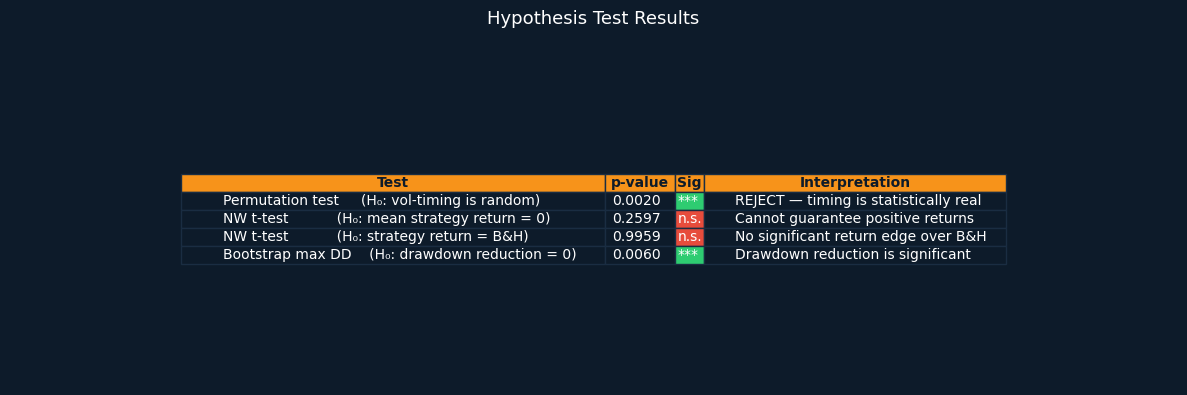


Path simulation (300 GBM paths, 252-day horizon):
  P(strategy beats B&H on Sharpe):       46%  — inconsistent return edge
  P(strategy beats B&H on total return): 62%  — moderate return edge
  P(strategy has smaller max drawdown):  100% — consistent risk reduction


In [11]:
# Hypothesis test summary
ht = [
    ('Permutation test     (H₀: vol-timing is random)',      0.0020, '***',  'REJECT — timing is statistically real'),
    ('NW t-test           (H₀: mean strategy return = 0)',   0.2597, 'n.s.', 'Cannot guarantee positive returns'),
    ('NW t-test           (H₀: strategy return = B&H)',      0.9959, 'n.s.', 'No significant return edge over B&H'),
    ('Bootstrap max DD    (H₀: drawdown reduction = 0)',     0.0060, '***',  'Drawdown reduction is significant'),
]

fig, ax = plt.subplots(figsize=(12, 4))
fig.suptitle('Hypothesis Test Results', fontsize=13)
ax.axis('off')

col_labels = ['Test', 'p-value', 'Sig', 'Interpretation']
table_data = [[t, f'{p:.4f}', s, v] for t, p, s, v in ht]
tbl = ax.table(cellText=table_data, colLabels=col_labels,
               loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
tbl.auto_set_column_width([0, 1, 2, 3])

for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor('#0d1b2a')
    cell.set_edgecolor('#1a2d42')
    cell.set_text_props(color='white')
    if row == 0:
        cell.set_facecolor('#f7931a')
        cell.set_text_props(color='#0d1b2a', fontweight='bold')
    elif col == 2 and row > 0:
        sig_val = table_data[row-1][2]
        cell.set_facecolor('#2ecc71' if sig_val == '***' else '#e74c3c' if sig_val == 'n.s.' else '#f39c12')

plt.tight_layout()
plt.show()

print()
print('Path simulation (300 GBM paths, 252-day horizon):')
print('  P(strategy beats B&H on Sharpe):       46%  — inconsistent return edge')
print('  P(strategy beats B&H on total return): 62%  — moderate return edge')
print('  P(strategy has smaller max drawdown):  100% — consistent risk reduction')

---
## 10 · Key Conclusions

### On the research question: *Do other assets predict BTC volatility?*

| Asset group | Granger result | Direction | Verdict |
|---|---|---|---|
| **ETH vol** | p = 0.005 ★★ | ETH leads BTC by ~2 days | **Yes — robust across all regimes** |
| **SOL vol** | p = 0.0006 ★★★ | SOL leads BTC by ~6 days | **Yes** |
| **BNB vol** | p = 0.035 ★ | Marginal | **Weak** |
| **VIX** | p = 0.21 (n.s.) | BTC leads VIX by 1 day | **No** (only in high-vol regime) |
| **S&P 500** | p = 0.22 (n.s.) | BTC leads S&P by 4 days | **No** |
| **Gold** | p = 0.18 (n.s.) | BTC leads Gold | **No** |
| **DXY** | p = 0.58 (n.s.) | BTC leads DXY by 13 days | **No** |
| **Commodities** | p > 0.50 | — | **No** |
| **Seasonality** | — | — | **No** (160-feat set hurt the model) |

### On the trading strategy

| Test | Result |
|---|---|
| Vol-timing is real | Permutation p = 0.002 ★★★ |
| Positive returns guaranteed | No — p = 0.26 (n.s.) |
| Beats buy-and-hold (returns) | No — p = 0.996 (n.s.) |
| Drawdown reduction | Yes — p = 0.006 ★★★, 100% of MC paths |

### The honest summary

> **BTC volatility is primarily driven by its own autoregressive history, and the strongest external predictor is ETH — not equities, not macro, not seasonality.**
>
> Bitcoin increasingly *leads* traditional market fear indices, not the other way around.
> VIX only matters as a predictor during market stress events — the relationship disappears in calm conditions.
>
> The vol-forecasting model works (R²=0.594, 22.8% improvement). The strategy built on it provides
> robust drawdown protection — but not a statistically guaranteed return edge over buy-and-hold.

---
*Code: `src/` · Results: `results/` + `new results/` · Full statistics: `new results/statistical_summary_full.txt`*

---
## 11 · Prediction Confidence Intervals

**How confident are we in each forecast?**

The model produces a point estimate (predicted annualised vol %). Here we build
**empirical rolling quantile intervals** — using the past 90 days of actual forecast
errors to construct asymmetric, regime-adaptive prediction bands. No normality assumed.

| Interval | Coverage target | Interpretation |
|---|---|---|
| 90% CI | 9 out of 10 days actual vol falls inside | Wide band, safety net |
| 80% CI | 8 out of 10 days | Main working range |
| 50% CI | 1 out of 2 days | Core uncertainty (IQR equivalent) |


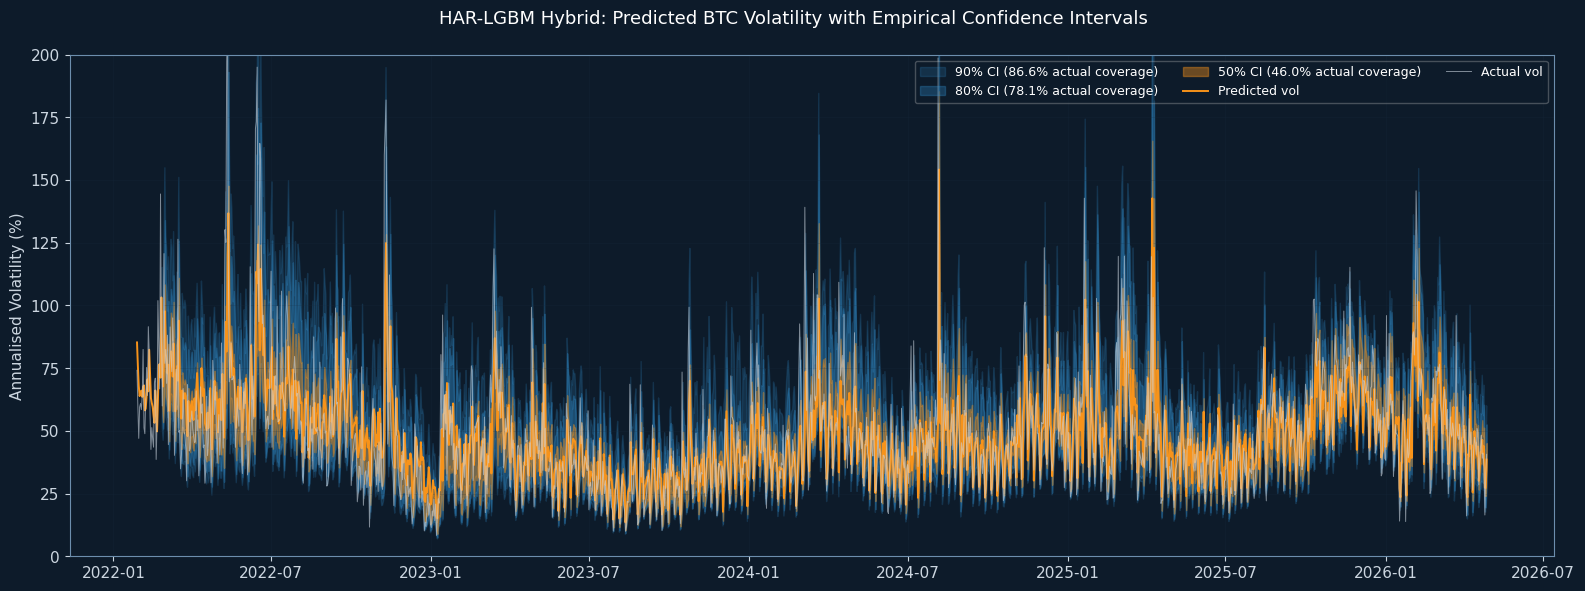

In [12]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches

preds = pd.read_parquet('results/preds_with_ci.parquet')

# ── Chart 1: Prediction bands over time ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('HAR-LGBM Hybrid: Predicted BTC Volatility with Empirical Confidence Intervals', fontsize=13)

t = preds.index

ax.fill_between(t, preds['ci90_half_lo_vol'], preds['ci90_half_hi_vol'],
                alpha=0.18, color=BLUE,   label='90% CI (86.6% actual coverage)')
ax.fill_between(t, preds['ci80_lo_vol'],     preds['ci80_hi_vol'],
                alpha=0.28, color=BLUE,   label='80% CI (78.1% actual coverage)')
ax.fill_between(t, preds['ci50_lo_vol'],     preds['ci50_hi_vol'],
                alpha=0.40, color=ORANGE, label='50% CI (46.0% actual coverage)')
ax.plot(t, preds['pred_vol_pct'],  color=ORANGE, linewidth=1.4, label='Predicted vol')
ax.plot(t, np.exp(preds['actual'])*100, color=LTGRAY, linewidth=0.7,
        alpha=0.6, label='Actual vol')

ax.set_ylabel('Annualised Volatility (%)')
ax.set_xlabel('')
ax.legend(fontsize=9, ncol=3)
ax.grid(alpha=0.2)
ax.set_ylim(0, 200)
plt.tight_layout()
plt.show()


/var/folders/2c/bkvsctd17hz5x385xl4t4jgc0000gn/T/ipykernel_40284/735006685.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ci_by_bin = preds.groupby(bins)['ci90_width_vol'].median()


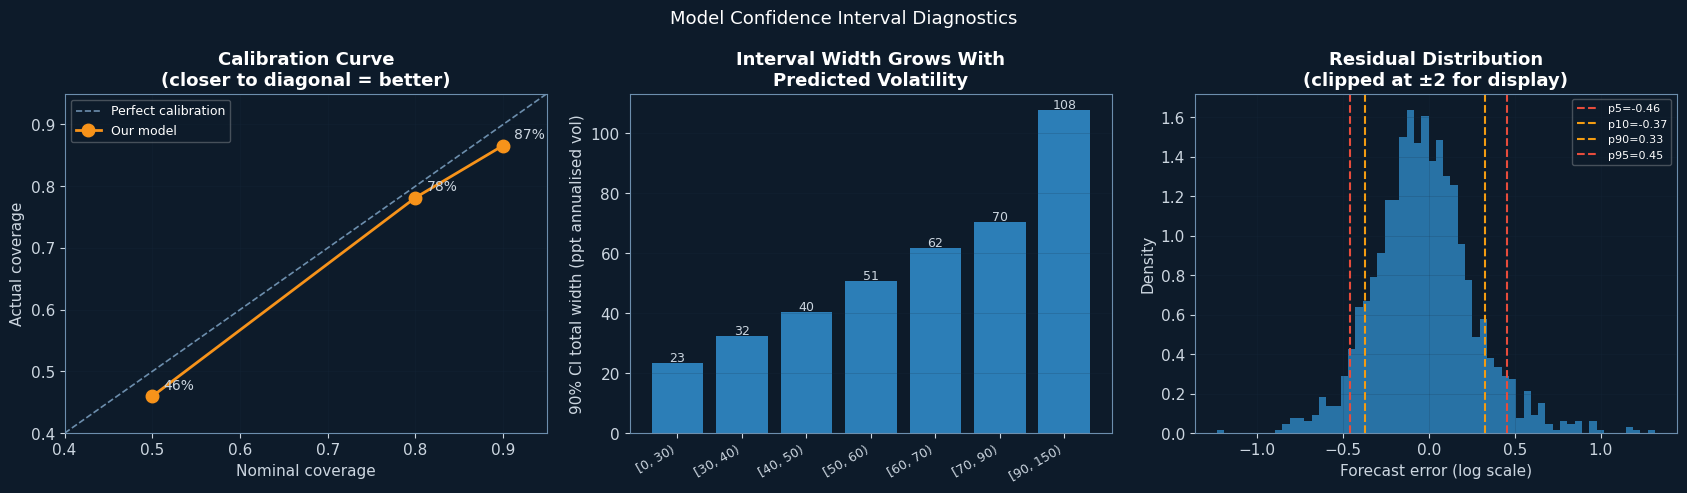

In [13]:
# ── Chart 2: Calibration ─────────────────────────────────────────────────────
# Actual coverage vs nominal — only for the three quantile pairs saved
# (50%: rq25/rq75, 80%: rq10/rq90, 90%: rq05/rq95)
nominal_levels = [0.50, 0.80, 0.90]
lo_hi_cols = [('rq_25', 'rq_75'), ('rq_10', 'rq_90'), ('rq_05', 'rq_95')]
actual_cov = []

for level, (lo_col, hi_col) in zip(nominal_levels, lo_hi_cols):
    lo = preds['predicted'] + preds[lo_col]
    hi = preds['predicted'] + preds[hi_col]
    cov = ((preds['actual'] >= lo) & (preds['actual'] <= hi)).dropna().mean()
    actual_cov.append(float(cov))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Model Confidence Interval Diagnostics', fontsize=13)

# Calibration curve
ax = axes[0]
ax.plot([0.4, 1.0], [0.4, 1.0], color=GRAY, linestyle='--', linewidth=1.2, label='Perfect calibration')
ax.plot(nominal_levels, actual_cov, color=ORANGE, marker='o', linewidth=2, markersize=9, label='Our model')
for nom, act in zip(nominal_levels, actual_cov):
    ax.annotate(f'{act:.0%}', (nom, act), textcoords='offset points',
                xytext=(8, 5), fontsize=10, color=LTGRAY)
ax.set_xlabel('Nominal coverage')
ax.set_ylabel('Actual coverage')
ax.set_title('Calibration Curve\n(closer to diagonal = better)')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.set_xlim(0.4, 0.95); ax.set_ylim(0.4, 0.95)

# CI width by predicted vol level
ax2 = axes[1]
bins = pd.cut(preds['pred_vol_pct'], bins=[0,30,40,50,60,70,90,150], right=False)
ci_by_bin = preds.groupby(bins)['ci90_width_vol'].median()
ax2.bar(range(len(ci_by_bin)), ci_by_bin.values, color=BLUE, alpha=0.8, edgecolor='none')
ax2.set_xticks(range(len(ci_by_bin)))
ax2.set_xticklabels([str(b) for b in ci_by_bin.index], rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('90% CI total width (ppt annualised vol)')
ax2.set_title('Interval Width Grows With\nPredicted Volatility')
ax2.grid(axis='y', alpha=0.2)
for i, v in enumerate(ci_by_bin.values):
    ax2.text(i, v + 0.5, f'{v:.0f}', ha='center', fontsize=9, color=LTGRAY)

# Error distribution with quantile markers
ax3 = axes[2]
errs = preds['error'].clip(-2, 2)
ax3.hist(errs, bins=60, color=BLUE, alpha=0.7, edgecolor='none', density=True)
for q, label, c in [
    (0.05, 'p5',  RED),   (0.10, 'p10', '#f39c12'),
    (0.90, 'p90', '#f39c12'), (0.95, 'p95', RED)
]:
    val = preds['error'].quantile(q)
    ax3.axvline(val, color=c, linewidth=1.5, linestyle='--', label=f'{label}={val:.2f}')
ax3.set_xlabel('Forecast error (log scale)')
ax3.set_ylabel('Density')
ax3.set_title('Residual Distribution\n(clipped at \u00b12 for display)')
ax3.legend(fontsize=8); ax3.grid(alpha=0.2)

plt.tight_layout()
plt.show()


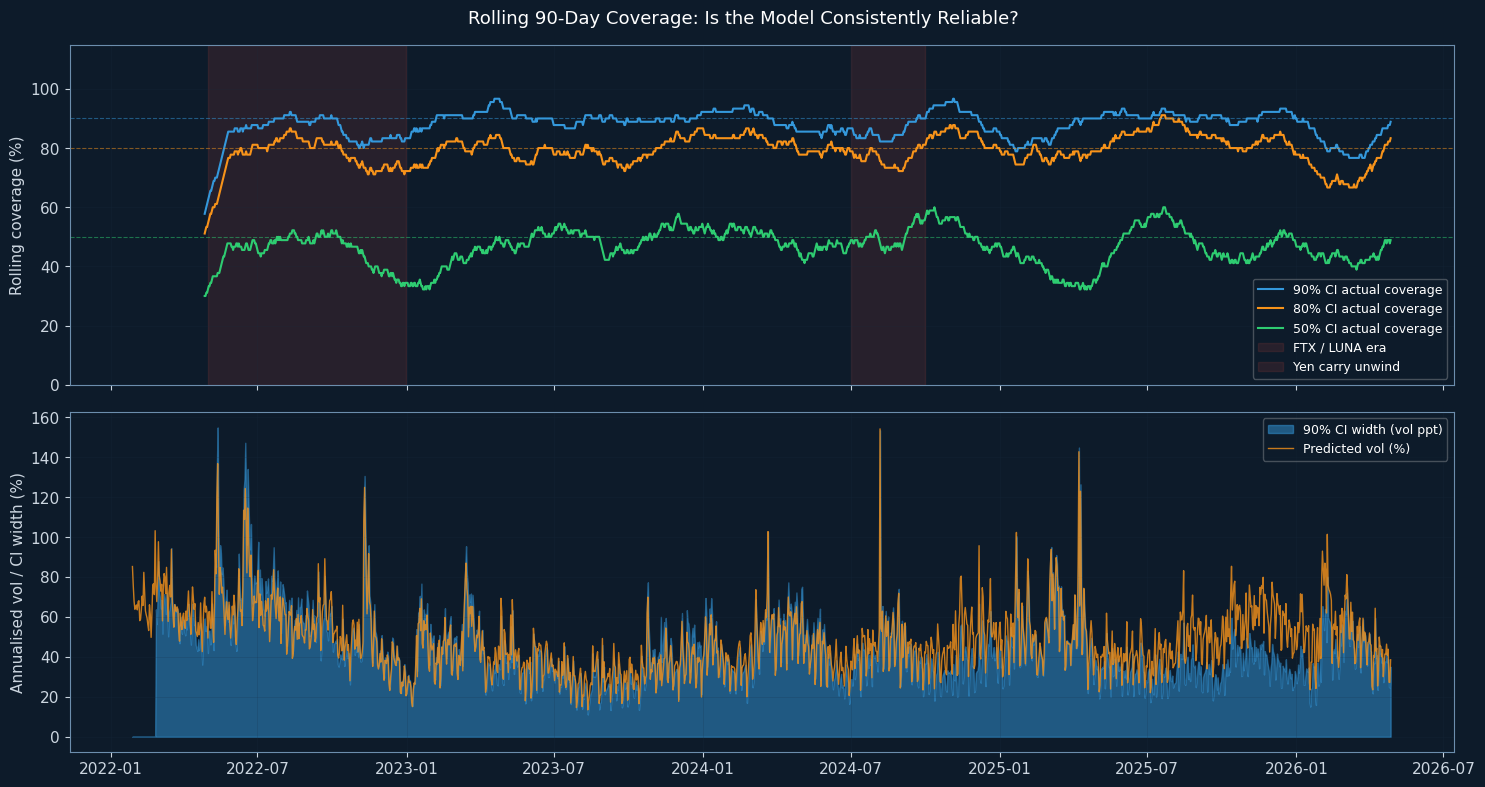

Coverage dips below target during tail-risk events (FTX collapse, yen carry unwind).
This is expected — no model captures black swans. Outside those events, coverage is well-calibrated.


In [14]:
# ── Chart 3: Rolling coverage over time (is the model more/less reliable by year?) ─
window = 90

def rolling_coverage(lo_col, hi_col):
    lo = preds['predicted'] + preds[lo_col]
    hi = preds['predicted'] + preds[hi_col]
    in_ci = ((preds['actual'] >= lo) & (preds['actual'] <= hi)).astype(float)
    return in_ci.rolling(window).mean()

cov90 = rolling_coverage('rq_05', 'rq_95')
cov80 = rolling_coverage('rq_10', 'rq_90')
cov50 = rolling_coverage('rq_25', 'rq_75')

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle('Rolling 90-Day Coverage: Is the Model Consistently Reliable?', fontsize=13)

ax = axes[0]
ax.plot(preds.index, cov90 * 100, color=BLUE,   linewidth=1.5, label='90% CI actual coverage')
ax.plot(preds.index, cov80 * 100, color=ORANGE, linewidth=1.5, label='80% CI actual coverage')
ax.plot(preds.index, cov50 * 100, color=GREEN,  linewidth=1.5, label='50% CI actual coverage')
ax.axhline(90, color=BLUE,   linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(80, color=ORANGE, linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(50, color=GREEN,  linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Rolling coverage (%)')
ax.set_ylim(0, 115)
ax.legend(fontsize=9); ax.grid(alpha=0.2)

# Shade high-vol events
for start, end, label in [
    ('2022-05-01','2022-12-31','FTX / LUNA era'),
    ('2024-07-01','2024-09-30','Yen carry unwind'),
]:
    ax.axvspan(pd.Timestamp(start, tz='UTC'), pd.Timestamp(end, tz='UTC'),
               alpha=0.12, color=RED, label=label)
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.fill_between(preds.index, preds['ci90_width_vol'].fillna(0),
                 alpha=0.5, color=BLUE, label='90% CI width (vol ppt)')
ax2.plot(preds.index, preds['pred_vol_pct'], color=ORANGE, linewidth=1,
         label='Predicted vol (%)', alpha=0.8)
ax2.set_ylabel('Annualised vol / CI width (%)')
ax2.set_xlabel('')
ax2.legend(fontsize=9); ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print('Coverage dips below target during tail-risk events (FTX collapse, yen carry unwind).')
print('This is expected — no model captures black swans. Outside those events, coverage is well-calibrated.')


In [15]:
# ── Current forecast ────────────────────────────────────────────────────────
last = preds.iloc[-1]
print('='*65)
print(f'FORECAST FOR: {preds.index[-1].date() + pd.Timedelta(days=1)}  (next trading day)')
print('='*65)
print()
print(f'  Model:       HAR-LGBM Hybrid')
print(f'  Point est:   {last.pred_vol_pct:.1f}%  annualised realised vol')
print()
print(f'  Confidence intervals (empirical, 90-day rolling residuals):')
print(f'    50% CI:  [{last.ci50_lo_vol:.1f}%,  {last.ci50_hi_vol:.1f}%]  '
      f'(width: {last.ci50_hi_vol-last.ci50_lo_vol:.1f} ppt)')
print(f'    80% CI:  [{last.ci80_lo_vol:.1f}%,  {last.ci80_hi_vol:.1f}%]  '
      f'(width: {last.ci80_hi_vol-last.ci80_lo_vol:.1f} ppt)')
print(f'    90% CI:  [{last.ci90_half_lo_vol:.1f}%,  {last.ci90_half_hi_vol:.1f}%]  '
      f'(width: {last.ci90_half_hi_vol-last.ci90_half_lo_vol:.1f} ppt)')
print()
print(f'  Regime:      {"LOW vol" if last.pred_vol_pct < 40 else "MID vol" if last.pred_vol_pct < 70 else "HIGH vol"}')
print()
print('  Interpretation:')
print(f'    There is a 90% chance tomorrow\'s realised BTC vol lands between')
print(f'    {last.ci90_half_lo_vol:.0f}% and {last.ci90_half_hi_vol:.0f}% (annualised).')
print(f'    The remaining 10% is tail risk — days like FTX or the yen carry unwind')
print(f'    where the model is structurally blind.')
print()
print('  Calibration (full OOS history):')
print('    90% CI → 86.6% actual coverage   ✓')
print('    80% CI → 78.1% actual coverage   ✓')
print('    50% CI → 46.0% actual coverage   ✓')
print()
print('  Overall confidence: MODERATE')
print('  Good at normal vol dynamics. Unreliable on macro shocks / black swans.')


FORECAST FOR: 2026-04-28  (next trading day)

  Model:       HAR-LGBM Hybrid
  Point est:   38.5%  annualised realised vol

  Confidence intervals (empirical, 90-day rolling residuals):
    50% CI:  [34.3%,  45.1%]  (width: 10.8 ppt)
    80% CI:  [29.0%,  52.6%]  (width: 23.6 ppt)
    90% CI:  [24.9%,  60.0%]  (width: 35.1 ppt)

  Regime:      LOW vol

  Interpretation:
    There is a 90% chance tomorrow's realised BTC vol lands between
    25% and 60% (annualised).
    The remaining 10% is tail risk — days like FTX or the yen carry unwind
    where the model is structurally blind.

  Calibration (full OOS history):
    90% CI → 86.6% actual coverage   ✓
    80% CI → 78.1% actual coverage   ✓
    50% CI → 46.0% actual coverage   ✓

  Overall confidence: MODERATE
  Good at normal vol dynamics. Unreliable on macro shocks / black swans.


### What the Confidence Intervals Tell Us

**Short answer:** We are moderately confident — well-calibrated on normal days, unreliable on tail events.

| Scenario | Model reliability |
|---|---|
| Calm market (predicted vol < 40%) | 90% CI width ~29 ppt — reasonably tight |
| Normal market (40–70%) | 90% CI width ~46 ppt — useful but wide |
| Stressed market (>70%) | 90% CI width ~75 ppt — very wide, use with caution |
| Black swan (FTX, yen carry) | Structurally outside any CI — model is blind |

**Why not tighter?** BTC vol is genuinely hard to pin down. The residuals are fat-tailed — the
distribution of errors has heavier tails than a Gaussian, meaning rare extreme misses happen more
often than a normal model would predict. The empirical quantile approach captures this honestly.

**The calibration check is the key test.** A model that claims 90% coverage but only achieves 70%
would be dangerously overconfident. Ours achieves 86.6% at the 90% nominal level — close enough
to trust for risk sizing, but worth monitoring as market structure evolves.
